# Dip Adjusted Samples

This notebook will enable plotting of dip adjusted samples

## Import packages

In [112]:
# general
import numpy as np
from tqdm import tqdm
import pandas as pd

# plotting
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib

# My packages
# my functions/classes
import sys
sys.path.append("../core_scripts/")
from ECMclass import ECM, core_section


## Set up

In [113]:
# Set filepaths

path_to_data = '../../data/'
path_to_samples = '../../data/sampling/master/'
path_to_angles = '../../data/angles/'
path_to_figures = '../../../figures/dip_adjusted_samples/'

path_to_final_figures = '../../../paper/final_figures/'

## Load Data

In [114]:
# load unit data
units = pd.read_excel(path_to_data+'sampling/units.xlsx')

In [115]:
# Load dip data
angles = pd.read_csv(path_to_angles + 'angles.csv')
angles.head()

,core,section,ACorDC,top_angle,left_angle,right_angle,side_angle,true_dip,true_dip_angles,true_dip_scores
0,alhic1901,228_4,AC,-36.776051,16.199769,-10.606322,13.403045,-38.643013,[-38.87808981 -38.54424142 -39.18075393 -37.73...,[0.88933205 0.97882252 0.95474921 0.95895482 0...
1,alhic1901,230_4,AC,27.819776,30.749623,-30.156336,30.452979,38.799076,[36.94242001 34.92239342 34.74296877 37.507310...,[0.99150915 0.99005042 0.99079277 0.99085791 0...


In [116]:
# Load ECM data

# Load metadata
meta = pd.read_csv(path_to_data + 'ecm/alligned/metadata.csv')
meta.head()

# set smoothing window
window = 10

# Load ECM data
data = []
cores = []
sections = []
faces = []
ACorDCs = []
for index, row in tqdm(meta.iterrows(), total=len(meta), desc="Processing data"):
    
    core = row['core']
        
    section = row['section']
    face = row['face']
    ACorDC = row['ACorDC']

    if ACorDC == 'AC' and not face == 'o':

        data_item = ECM(core,section,face,ACorDC,path_to_data + 'ecm/alligned/')
        print("Reading "+core+", section "+section+'-'+face+'-'+ACorDC)
        
        data_item.rem_ends(15)
        data_item.smooth(window)
        data.append(data_item)
        
        cores.append(core)
        sections.append(section)
        faces.append(face)
        ACorDCs.append(ACorDC)
        

# Put ECM data into core_section structure
s228_4_AC = core_section('228_4','alhic1901','AC',data,sections,faces,cores,ACorDCs)
s230_4_AC = core_section('230_4','alhic1901','AC',data,sections,faces,cores,ACorDCs)

# place in 3D space
for s in [s228_4_AC,s230_4_AC]:
    s.add_3d_coords()

# add angles
for s in [s228_4_AC,s230_4_AC]:
    s.get_angles(angles)


Processing data:   0%|          | 0/14 [00:00<?, ?it/s]

Reading alhic1901, section 228_4-l-AC


Processing data:  29%|██▊       | 4/14 [00:00<00:00, 14.89it/s]

Reading alhic1901, section 230_4-l-AC


Processing data:  43%|████▎     | 6/14 [00:00<00:00, 10.63it/s]

...

Reading alhic1901, section 228_4-r-AC


Processing data:  79%|███████▊  | 11/14 [00:02<00:00,  4.92it/s]

Reading alhic1901, section 228_4-t-AC


Processing data: 100%|██████████| 14/14 [00:02<00:00,  5.36it/s]

No data found for opposite face of section 228_4 in core alhic1901
No data found for opposite face of section 230_4 in core alhic1901
The 'opposite' face does not exist for this core section.
The 'opposite' face does not exist for this core section.


In [117]:
# load sample data
samps = ['water_iso','cc','ic_icpms','cfa','ghg']

# loop through and load all sample files
for s in samps:

    if s == samps[0]:
        samp_data_raw = pd.read_csv(path_to_samples + s+'_master.csv')

    else:

        df = pd.read_csv(path_to_samples + s+'_master.csv')
        samp_data_raw = pd.concat([samp_data_raw, df], ignore_index=True)

## Make some functions

In [118]:
def plot_ecm(axs,face,top_angle,cmap,rescale):

    res = 0.002

    meas = face.meas_s
    button = face.button_s
    ycor = face.y_s
    d = face.depth_s
    x_vector = face.x_3d
    y_vector = face.y_3d
    tracks = np.unique(x_vector)

    # define width of track
    width = tracks[2] - tracks[1]

    for x in tracks:
        
        # Pull out data for this track
        idx = x_vector==x
        tmeas = meas[idx]
        tbut = button[idx]
        td = d[idx]

        # calculate the shift
        depth_shift = x * np.tan(top_angle * np.pi/180)
        td = td + depth_shift

        # downsample ECM to save plotting time (as needed)
        if res != 0:
            int_lo = round(min(td),3)
            int_hi = round(max(td),3)
            depth_interp = np.linspace(int_lo,int_hi,int((int_hi-int_lo)/res)+1)
            meas_interp = np.interp(depth_interp,np.flip(td),np.flip(tmeas))
            but_interp = np.interp(depth_interp,np.flip(td),np.flip(tbut))
            td = depth_interp
            tmeas = meas_interp
            tbut = np.round(but_interp)
        
        for i in range(len(tmeas)-1):
            
            if tbut[i] == 0:
                axs.add_patch(Rectangle((x-(width)/2,td[i]),(width),td[i+1]-td[i],facecolor=cmap(rescale(tmeas[i]))))
            else:
                axs.add_patch(Rectangle((x-(width)/2,td[i]),(width),td[i+1]-td[i],facecolor=cmap(rescale(tmeas[i]))))

    

In [119]:
# plot sample
def plot_sample(ax0,axs,samp_data_all,top_angle,side_angle,cmap,p,proxies,section):

    linewidth = 0.8

    # # get the count
    # samp_data_allprox = samp_data_all[samp_data_all[proxies].notna().any(axis=1)]
    # sticks_all = samp_data_allprox['stick'].unique()

    # filter samp_data for only rows where the column p is not empty
    samp_data_all = samp_data_all[samp_data_all[p].notna()]

    #get unique values in column 'sticks'
    sticks = samp_data_all['stick'].unique()

    # filter samp_data for only rows where 'section' is equal to sec.section
    samp_data = samp_data_all[samp_data_all['section'] == section]

    # loop through each unique value in column 'sticks'
    for s in sticks:

        # filter samp_data for only rows where the column 'sticks' is equal to s
        df = samp_data[samp_data['stick'] == s].copy()

        # compute the shift
        shift = df['effective_center_x'] * np.tan(top_angle * np.pi/180) + df['effective_center_y'] * np.tan(side_angle * np.pi/180)
        df['mid_depth_shifted'] = df['mid_depth'] + shift
        df['top_depth_shifted'] = df['top_depth'] + shift
        df['bottom_depth_shifted'] = df['bottom_depth'] + shift

        # compute shifts for four corners of the cube
        left_shift = df['x_lo'] * np.tan(top_angle * np.pi/180) + df['effective_center_y'] * np.tan(side_angle * np.pi/180)
        right_shift =  df['x_hi'] * np.tan(top_angle * np.pi/180) + df['effective_center_y'] * np.tan(side_angle * np.pi/180)

        df['top_depth_left'] = df['top_depth'] + left_shift
        df['top_depth_right'] = df['top_depth'] + right_shift
        df['bottom_depth_left'] = df['bottom_depth'] + left_shift
        df['bottom_depth_right'] = df['bottom_depth'] + right_shift

        # get the color
        if not df.empty:

            color = cmap(int(df['default_color'].mean()))

            # plot the line
            axs.plot(df[p],df['mid_depth_shifted'],color=color,linewidth=linewidth)

            for index,row in df.iterrows():

                # plot the cube
                
                ax0.plot([row['x_lo'],row['x_hi']],[row['top_depth_left'],row['top_depth_right']],color=color,linewidth=linewidth)
                ax0.plot([row['x_lo'],row['x_hi']],[row['bottom_depth_left'],row['bottom_depth_right']],color=color,linewidth=linewidth)
                ax0.plot([row['x_lo'],row['x_lo']],[row['bottom_depth_left'],row['top_depth_left']],color=color,linewidth=linewidth)
                ax0.plot([row['x_hi'],row['x_hi']],[row['bottom_depth_right'],row['top_depth_right']],color=color,linewidth=linewidth)
                # ax0.plot([row['x_lo'],row['x_hi'],row['x_hi'],row['x_lo'],row['x_lo']],
                #          [row['top_depth_right'],row['top_depth_right'],row['bottom_depth_left'],row['bottom_depth_left'],row['top_depth_right']],
                #          color=color)

                # plot the line
                axs.plot([row[p],row[p]],[row['top_depth_shifted'],row['bottom_depth_shifted']],color=color,linewidth=linewidth)


In [123]:
def make_full_plot(samp_data,secs,proxies,side_angles_after,top_angles_after,d_ranges,title=None):

    # set colormap - ecm
    my_cmap = matplotlib.colormaps['Spectral']

    # set colormap - lines
    cmap_line = matplotlib.colormaps['tab10']

    # filter samp_data for only rows where 'section' is in the list of sections from secs
    sections = [sec.section for sec in secs]
    samp_data_sec = samp_data[samp_data['section'].isin(sections)]

    # define rescale
    meas_all = np.array([])
    for sec in secs:
        meas_all = np.concatenate((meas_all,sec.top.meas_s))
    pltmin = np.percentile(meas_all,5)
    pltmax = np.percentile(meas_all,95)
    rescale = lambda k: (k-pltmin) /  (pltmax-pltmin)

    # make figure - figure out width ratios for one side
    ratios_side = [5]
    numplots_side = 2
    if len(proxies)>0:
        numplots_side = 1+len(proxies)
    for i in range(len(proxies)):
        ratios_side.append(2.5)

    # insert a spacer column between left (before) and right (after) halves to create a larger middle gap
    spacer_width = 0.6  # adjust to change middle gap
    ratios = ratios_side + [spacer_width] + ratios_side
    numplots_total = len(ratios)  # total columns

    # compute spacer and title column indices (defined before use)
    spacer_col = numplots_side
    left_title_col = 0
    right_title_col = spacer_col + 1
    rightmost_col = numplots_total - 1

    # make figure - figure out height ratios
    h_ratios = []
    for d in d_ranges:
        h_ratios.append(abs(d[1]-d[0]))
    ave = sum(h_ratios)/len(h_ratios)
    h_ratios = [x/ave for x in h_ratios]

    # make figure. keep internal wspace very small so ECM and proxy plots within a half are tight;
    #fig, ax = plt.subplots(len(secs), numplots_total, figsize=(12+len(proxies)*3, 6*len(d_ranges)), gridspec_kw={'width_ratios': ratios, 'height_ratios': h_ratios}, dpi=100)
    fig, ax = plt.subplots(len(secs), numplots_total, figsize=(7,7), gridspec_kw={'width_ratios': ratios, 'height_ratios': h_ratios}, dpi=300)

    # normalize ax to 2D array for consistent indexing
    import numpy as _np
    if ax.ndim == 1:
        ax = _np.expand_dims(ax, 0) if len(secs)>1 else _np.expand_dims(_np.expand_dims(ax,0),0)

    # titles for halves (font size increased) -- shift each title slightly to the right
    ax[0,left_title_col].set_title('Before Dip Adjustment', fontsize=10, x=0.8)
    ax[0,right_title_col].set_title('After Dip Adjustment', fontsize=10, x=0.8)

    # prepare before (zeros) and after angle arrays
    before_top_angles = [0.0]*len(secs)
    before_side_angles = [0.0]*len(secs)
    after_top_angles = top_angles_after
    after_side_angles = side_angles_after

    # iterate through sections and plot both halves
    cnt = 0
    for sec, d_range in zip(secs, d_ranges):

        # set top and bottom depths
        td = d_range[1]
        bd = d_range[0]

        # set axis limits and enforce 0.1 spacing on y-axis ticks for every subplot
        for col in range(numplots_total):
            ax[cnt,col].set_ylim([bd,td])
            ax[cnt,col].yaxis.set_major_locator(plt.MultipleLocator(0.1))
            ax[cnt,col].tick_params(axis='y', which='major', labelsize=8)

        # for both halves: 0=before (left), 1=after (right)
        for half_idx, (ta_list, sa_list) in enumerate([(before_top_angles, before_side_angles),(after_top_angles, after_side_angles)]):

            # compute column offset; after half shifts by spacer
            if half_idx == 0:
                col_offset = 0
            else:
                col_offset = spacer_col + 1

            top_angle = ta_list[cnt]
            side_angle = sa_list[cnt]

            # plot ECM in the first column of this half
            plot_ecm(ax[cnt,col_offset], sec.top, top_angle, my_cmap, rescale=rescale)

            # loop through proxies and plot samples in subsequent columns of this half
            for i in range(len(proxies)):
                p = proxies[i]
                axs = ax[cnt,col_offset + i + 1]
                plot_sample(ax[cnt,col_offset], axs, samp_data_sec, top_angle, side_angle, cmap_line, p, proxies, sec.section)

                # figure axis limits & housekeeping
                prox_data_min = samp_data_sec[p].min()
                prox_data_max = samp_data_sec[p].max()
                cushion = abs(prox_data_max - prox_data_min) * 0.05
                axs.set_xlim([prox_data_min-cushion,prox_data_max+cushion])

                # remove x-axis labels from the upper set of plots (top row)
                if cnt == 0:
                    axs.set_xticks([])
                    axs.set_xticklabels([])
                # only bottom row gets x-axis label for proxies (font size 16)
                if cnt == len(secs)-1:
                    unit_row = units.loc[units['simple_name'] == p]
                    if len(unit_row) == 1:
                        full_name = unit_row.latex_name.iloc[0]
                        unit = unit_row.units.iloc[0]
                    else:
                        full_name = p
                        unit = ''
                    axs.set_xlabel(full_name + ' (' + unit + ')',fontsize=8)

                # enforce 0.1 y ticks and consistent tick label size
                axs.yaxis.set_major_locator(plt.MultipleLocator(0.1))
                axs.tick_params(axis='both', which='major', labelsize=16)

        # grid and increment -- apply y-grid to all columns except the spacer column
        for col_idx, a in enumerate(ax[cnt,:]):
            if col_idx != spacer_col:
                a.grid(axis='y')
        cnt += 1

    # place x-axis label under ECM plots (bottom row only) for both halves (fontsize 16)
    ax[len(secs)-1, left_title_col].set_xlabel('Distance across core (m)', fontsize=8)
    ax[len(secs)-1, right_title_col].set_xlabel('Distance across core (m)', fontsize=8)

    # 1) remove x-axis ticks/labels from the entire top row
    for col in range(numplots_total):
        ax[0,col].set_xticks([])
        ax[0,col].set_xticklabels([])

    # 2) Remove x-axis ticks & labels from spacer column for all rows
    for row in range(len(secs)):
        ax[row, spacer_col].set_xticks([])
        ax[row, spacer_col].set_xticklabels([])
        ax[row, spacer_col].set_xlabel('')
        # hide horizontal spine lines (top and bottom) for spacer column only, keep vertical spines visible
        ax[row, spacer_col].spines['top'].set_visible(False)
        ax[row, spacer_col].spines['bottom'].set_visible(False)
        ax[row, spacer_col].spines['left'].set_visible(True)
        ax[row, spacer_col].spines['right'].set_visible(True)

    # 3) Y-axis labels only on leftmost and rightmost plotted columns; clear ticks/labels from all other columns
    for row in range(len(secs)):
        for col in range(numplots_total):
            if col == 0:
                if row == 0:
                    ax[row,col].set_ylabel('Sec. 228_4\nDepth (m)', fontsize=8)
                else:
                    ax[row,col].set_ylabel('Sec. 230_4\nDepth (m)', fontsize=8)
                ax[row,col].yaxis.set_label_position('left')
                ax[row,col].yaxis.tick_left()
                ax[row,col].tick_params(axis='y', which='major', labelsize=8)
            elif col == rightmost_col:
                if row == 0:
                    ax[row,col].set_ylabel('Dip-Adj. Depth (m)\nSec. 228_4', fontsize=8)
                else:
                    ax[row,col].set_ylabel('Dip-Adj. Depth (m)\nSec. 230_4', fontsize=8)
                ax[row,col].yaxis.set_label_position('right')
                # ax[row,col].yaxis.tick_right()
                # ax[row,col].tick_params(axis='y', which='major', labelsize=8)

                # turn off ticks and tick labels for rightmost column to avoid clutter
                ax[row,col].set_yticks([])
                ax[row,col].set_yticklabels([])
            else:
                # remove y ticks and labels for interior columns (including spacer)
                ax[row,col].set_yticks([])
                ax[row,col].set_yticklabels([])

    # Ensure 0.1 y-axis spacing on all subplots and set tick label sizes to 8
    for row in range(len(secs)):
        for col in range(numplots_total):
            ax[row,col].yaxis.set_major_locator(plt.MultipleLocator(0.1))
            ax[row,col].tick_params(axis='both', which='major', labelsize=8)

    # remove y-axis tick marks (the short tick lines) from interior columns while keeping left/right tick marks visible
    for row in range(len(secs)):
        for col in range(numplots_total):
            if col not in (0, rightmost_col):
                # remove tick mark lines but keep any (already removed) labels unaffected
                ax[row,col].tick_params(axis='y', which='both', length=0)

    # Final layout: internal spacing minimal, rely on spacer column for middle gap
    fig.tight_layout(rect=[0.02, 0, 0.98, 0.95])
    plt.subplots_adjust(wspace=0.0)
    plt.subplots_adjust(hspace=0.01)

    # add colorbar (use leftmost ECM subplot to anchor)
    cbar_ax = fig.add_axes([ax[0,0].get_position().x0,-0.03,ax[0,0].get_position().x1-ax[0,0].get_position().x0,0.03])
    norm = matplotlib.colors.Normalize(vmin=pltmin,vmax=pltmax)
    cbar = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=my_cmap),cax=cbar_ax,
                    orientation='horizontal',label='AC Current (amps)')
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label('AC Current (amps)', fontsize=8)

    # add subplot labels ("(a)", "(b)", etc.) to upper left corner of each ECM subplot (font size 8)
    subplot_labels = ['(a)', '(b)', '(c)', '(d)']
    cnt = 0
    for row in range(len(secs)):
        for col in range(numplots_total):
            if col in (0, spacer_col + 1):  # only label the ECM columns
                ax[row,col].text(0.02, 0.95, subplot_labels[cnt], transform=ax[row,col].transAxes, fontsize=12, verticalalignment='top')
                cnt += 1


    # save plot
    plt.savefig(
        path_to_figures 
        + f"Combined_before-after_{'_'.join(proxies)}_top{np.mean(top_angles_after):.2f}_side{np.mean(side_angles_after):.2f}.png",
        bbox_inches='tight',
        dpi=300,
    )

    return fig, ax

In [121]:
# define function inputs (temporary)
sec = s228_4_AC
proxies = ['d18O','co2']
side_angle = None
top_angle = None

## Now let's make some plots!!!

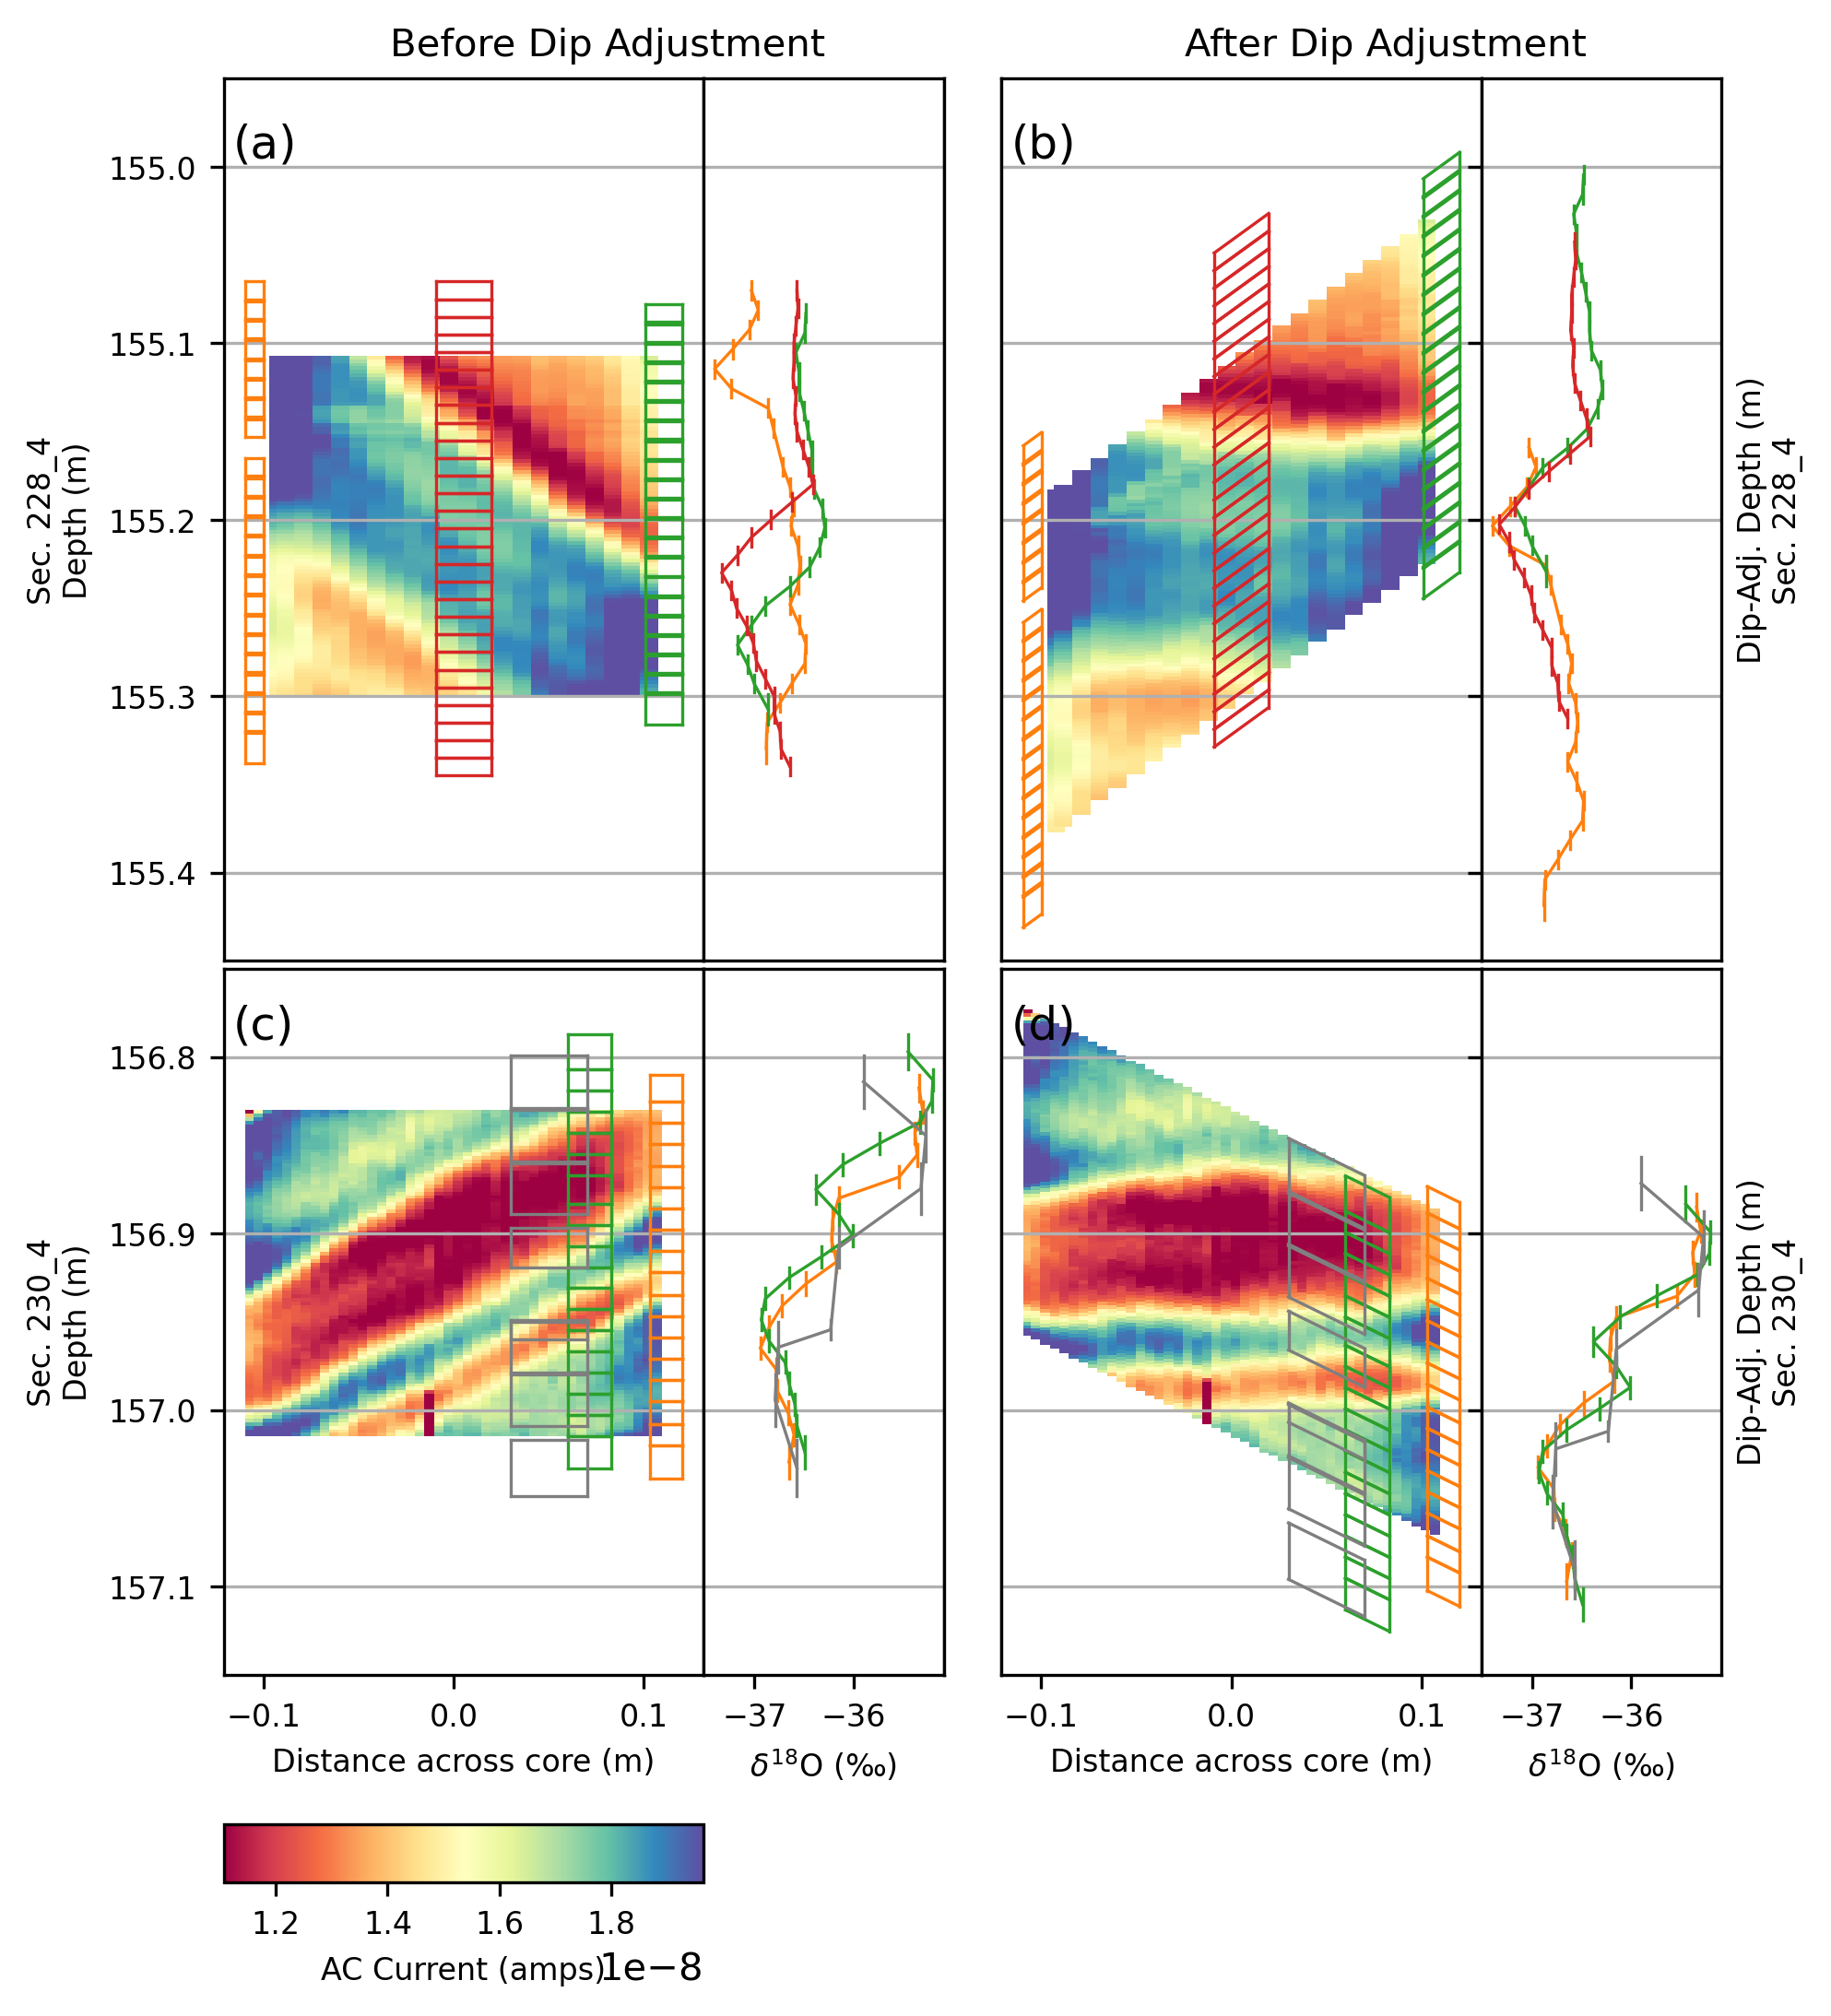

In [124]:
secs = [s228_4_AC,s230_4_AC]
proxies = ['d18O']
d_range = [[155.45, 154.95],[157.15,156.75]]
side_angles_after = [s228_4_AC.side_angle, s230_4_AC.side_angle]
top_angles_after = [s228_4_AC.top_angle, s230_4_AC.top_angle]
fig, ax = make_full_plot(samp_data_raw, secs, proxies, side_angles_after, top_angles_after, d_range, title=None)

# save final figure as pdf and png
fig.savefig(path_to_final_figures+'pdf/figure4.pdf', dpi=300)
fig.savefig(path_to_final_figures+'png/figure4.png', dpi=300)